# Kalman filters for motion prediction in tracking

A tracker has to answer one question every frame: *given everything
I have seen so far, where is each object now — and how sure am I?*
A **Kalman filter** answers both at once. It carries, per object, a
Gaussian belief over a latent state (position, velocity, size, …)
and rolls it forward in two steps:

- **Predict** — push the belief through a motion model
  $x' = F x$, and grow its covariance $P' = F P F^\top + Q$. This is
  the filter's guess about the *next* frame, *before* it sees any
  detection. It is a full distribution, not a point.
- **Update** — when a detection arrives, fuse it (Joseph-form Kalman
  gain), pulling the mean toward the measurement and *shrinking* the
  covariance by however much the measurement was worth.

This notebook visualizes that loop for the five state types unitrack
ships a Kalman model for:

| State | unitrack class | latent state | measurement |
|---|---|---|---|
| 2-D point | `KalmanCentroid2D` | `[x, y, vx, vy]` | `[x, y]` |
| 2-D box | `KalmanBBox` (SORT) | `[x, y, a, h, vx, vy, va]` | `[x, y, a, h]` |
| 2-D mask | `KalmanCentroid2D` on the mask centroid | `[x, y, vx, vy]` | `[x, y]` |
| 3-D point cloud | `KalmanCentroid3D` | `[x,y,z, vx,vy,vz]` | `[x, y, z]` |
| kernel / appearance | `KalmanLinear` (random walk) | `[e₁ … e_d]` | `[e₁ … e_d]` |

For points, boxes and masks we draw the **object's trajectory over
time** *and* the filter's **one-step-ahead predictive distribution**
— the ellipse it would hand an association gate as "the detection
should land about here." The last section stress-tests the filter:
where it shines (occlusion, noise) and where it breaks (maneuvers,
bad tuning, crossing targets).


## Setup

Everything here is pure `unitrack` + `matplotlib`. We drive the
Kalman `Process` (predict) and its paired `KalmanUpdate`
(observation) directly, frame by frame, instead of wrapping them in
a full `Tracker` — that keeps the *belief itself* in view, which is
the whole point.


In [1]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle

from unitrack.data import Detections, FrameContext, MatchOutcome, Tracklets
from unitrack.lifecycle import TrackletStatus
from unitrack.states.kalman import (
    KalmanBBox, KalmanCentroid2D, KalmanCentroid3D,
    KalmanLinear, KalmanUpdate,
)

torch.manual_seed(0)
plt.rcParams["figure.figsize"] = (7, 4)


### A thin driver around the unitrack Kalman API

`KalmanCentroid2D`, `KalmanCentroid3D` and `KalmanBBox` are each a
`Process` (the predict step, `proc(cs, ctx)`) plus a `make_update()`
factory that returns the matching `KalmanUpdate`. Both read the mean
from `cs.{field}` and the covariance from `cs.{field}_cov`. The
helpers below wrap a single object into a one-row `Tracklets`
snapshot and run a sequence of measurements through
predict → (optional) update, recording the belief at every frame.


In [2]:
def one_tracklet(field, mean, cov):
    """Wrap a single (mean, cov) pair into a 1-row Tracklets snapshot."""
    return Tracklets(
        id=torch.tensor([1], dtype=torch.int64),
        status=torch.tensor([int(TrackletStatus.Active)], dtype=torch.int8),
        hits=torch.tensor([1], dtype=torch.int32),
        time_since_update=torch.zeros(1, dtype=torch.int32),
        age=torch.ones(1, dtype=torch.int32),
        frame_started=torch.zeros(1, dtype=torch.int32),
        frame_last_seen=torch.zeros(1, dtype=torch.int32),
        **{field: mean.unsqueeze(0).float(),
           f"{field}_cov": cov.unsqueeze(0).float()},
        batch_size=[1],
    )

def match_one():
    """A MatchOutcome pairing tracklet 0 with detection 0."""
    return MatchOutcome(
        matched_pairs=torch.tensor([[0, 0]], dtype=torch.int64),
        tracklets_residual_index=torch.zeros(0, dtype=torch.int64),
        detections_residual_index=torch.zeros(0, dtype=torch.int64),
        per_match_cost=torch.zeros(1),
        batch_size=[],
    )

def run_kalman(proc, init_mean, init_cov, measurements, present, *,
               dt=1.0, dts=None, gate_chi2=None):
    """
    Drive a unitrack Kalman process over a sequence.

    Returns one record per frame holding the *prior* (post-predict,
    pre-update) belief — where the filter expects the object to be
    *before* the new detection — and the *posterior* after fusion.
    On a missed frame (``present[k]`` False) no update runs, so the
    prior carries forward: pure coasting.

    Parameters
    ----------
    dt : float
        Constant time step (used when ``dts`` is None).
    dts : sequence of float, optional
        Per-frame time step, for irregular frame rates. Each predict
        uses ``delta=dts[k]`` so ``F`` and ``Q`` scale with real time.
    gate_chi2 : float, optional
        If set, a detection whose squared Mahalanobis distance to the
        predictive distribution exceeds this threshold is *rejected*
        (treated as a miss). This is the standard outlier gate; the
        record's ``"gated"`` flag marks rejected frames.
    """
    field = proc.field
    upd = proc.make_update()
    snap = one_tracklet(field, init_mean, init_cov)
    out = []
    for k, seen in enumerate(present):
        delta = float(dts[k]) if dts is not None else dt
        ctx = FrameContext.make(frame_idx=k, delta=delta)
        snap = proc(snap, ctx)                              # PREDICT
        prior_mean = getattr(snap, field)[0].clone()
        prior_cov = getattr(snap, f"{field}_cov")[0].clone()
        rec = {"prior_mean": prior_mean, "prior_cov": prior_cov,
               "seen": seen, "gated": False}
        if seen:
            z = measurements[k].float()
            m = z.shape[0]
            if gate_chi2 is not None:
                S = prior_cov[:m, :m] + torch.eye(m) * proc.r
                inn = (z - prior_mean[:m]).double()
                md2 = float(inn @ torch.linalg.inv(S.double()) @ inn)
                rec["gated"] = md2 > gate_chi2
            if not rec["gated"]:
                ds = Detections(index=torch.tensor([0], dtype=torch.int64),
                                **{field: z.unsqueeze(0)}, batch_size=[1])
                snap = upd(snap, ds, match_one(), ctx)     # UPDATE
        rec["post_mean"] = getattr(snap, field)[0].clone()
        rec["post_cov"] = getattr(snap, f"{field}_cov")[0].clone()
        out.append(rec)
    return out


In [3]:
# --- plotting helpers -------------------------------------------------

def cov_ellipse(ax, mean2, cov2, n_std=2.0, **kw):
    """Draw an n-sigma covariance ellipse for a 2-D Gaussian."""
    cov2 = cov2.detach().cpu().double()
    vals, vecs = torch.linalg.eigh(cov2)
    vals = vals.clamp(min=1e-12)
    order = torch.argsort(vals, descending=True)
    vals, vecs = vals[order], vecs[:, order]
    angle = math.degrees(math.atan2(float(vecs[1, 0]), float(vecs[0, 0])))
    width, height = (2 * n_std * vals.sqrt()).tolist()
    ax.add_patch(Ellipse((float(mean2[0]), float(mean2[1])),
                         width, height, angle=angle, fill=False, **kw))

def predictive_xy(rec, r, n=2):
    """
    One-step-ahead measurement distribution for the position block.

    For these models H = [I | 0], so the predicted measurement mean
    is the leading ``n`` state entries and its covariance is the
    leading n-by-n block of P plus the measurement noise R = r*I.
    """
    mu = rec["prior_mean"][:n]
    S = rec["prior_cov"][:n, :n] + torch.eye(n) * r
    return mu, S

def fade(cmap_name, k, n):
    """A time-graded color: early frames light, late frames saturated."""
    return plt.get_cmap(cmap_name)(0.25 + 0.7 * k / max(1, n - 1))


## 1 — Points: a 2-D centroid

The canonical case. A constant-velocity object drifts across the
frame; the detector reports its centroid with Gaussian noise.
`KalmanCentroid2D` carries `[x, y, vx, vy]` and observes `[x, y]`.

Below, the grey curve is the true path, red ✕ are the noisy
detections, and the blue line is the filter's posterior estimate.
The **green ellipses** are what makes the filter a filter: at sampled
frames, the 2σ region where the filter — using only *past*
detections — expects the *next* detection to fall. A χ²/Mahalanobis
gate is exactly "is the detection inside this ellipse?".


In [4]:
T = 22
t = torch.arange(T).float()
true_xy = torch.stack([2.0 * t, 12.0 + 0.06 * (t - 11) ** 2], dim=1)
g = torch.Generator().manual_seed(3)
sigma = 1.4
meas = true_xy + sigma * torch.randn(T, 2, generator=g)

proc = KalmanCentroid2D("centroid", q=0.08, r=sigma ** 2)
init_mean = torch.tensor([float(meas[0, 0]), float(meas[0, 1]), 2.0, 0.0])
init_cov = torch.diag(torch.tensor([4.0, 4.0, 4.0, 4.0]))
rec = run_kalman(proc, init_mean, init_cov, list(meas), [True] * T)
post = torch.stack([r["post_mean"][:2] for r in rec])


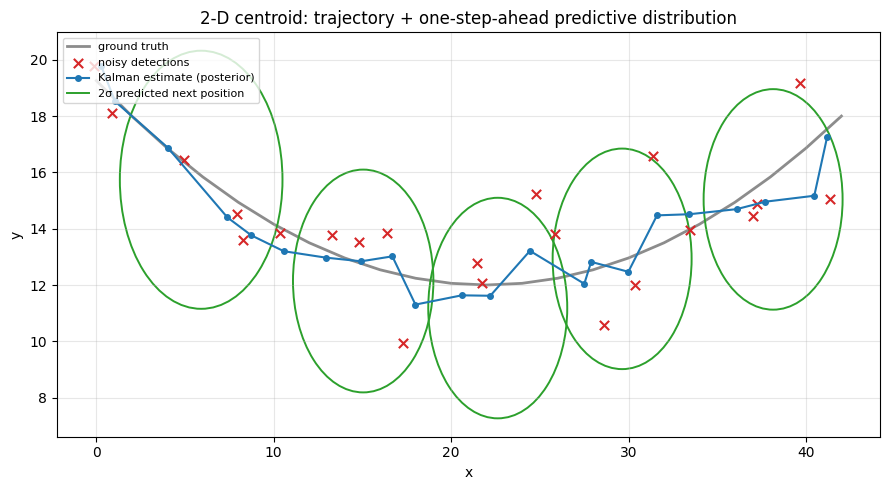

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(true_xy[:, 0], true_xy[:, 1], "-", color="0.55", lw=2,
        label="ground truth", zorder=1)
ax.scatter(meas[:, 0], meas[:, 1], marker="x", color="tab:red", s=45,
           label="noisy detections", zorder=2)
ax.plot(post[:, 0], post[:, 1], "o-", color="tab:blue", ms=4,
        label="Kalman estimate (posterior)", zorder=3)
for k in range(3, T, 4):
    mu, S = predictive_xy(rec[k], proc.r)
    cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:green", lw=1.4)
ax.plot([], [], color="tab:green", lw=1.4,
        label="2σ predicted next position")
ax.set_title("2-D centroid: trajectory + one-step-ahead predictive distribution")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Predicting through an occlusion

The predictive distribution is most useful when there is *no*
detection to fall back on. Here the object is occluded for six
frames (no detections, frames 7–12). With no measurement to fuse,
the filter keeps predicting: the mean coasts along the last known
velocity and the covariance **grows** every frame — the ellipses
balloon, honestly reporting "it's somewhere in here, and I'm less
and less sure." When the object reappears, one detection collapses
the uncertainty again.


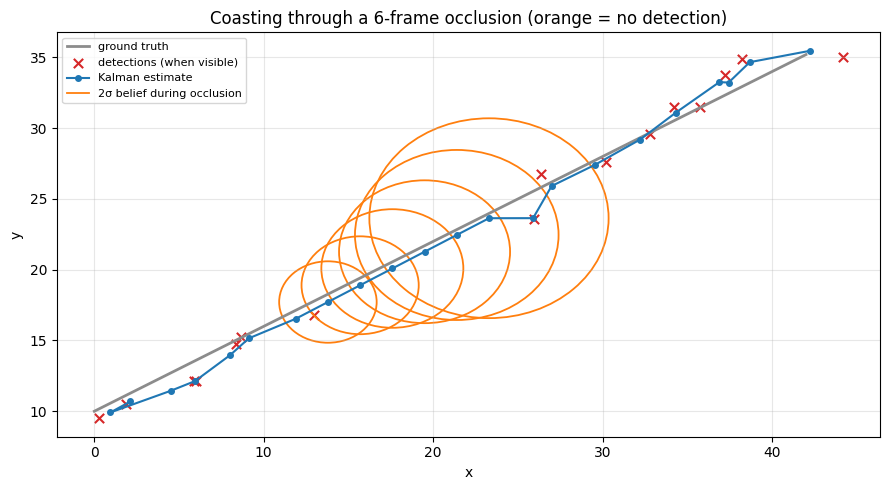

In [6]:
present = [True] * 7 + [False] * 6 + [True] * 9
T2 = len(present)
t2 = torch.arange(T2).float()
true2 = torch.stack([2.0 * t2, 10.0 + 1.2 * t2], dim=1)
g = torch.Generator().manual_seed(5)
meas2 = true2 + 1.0 * torch.randn(T2, 2, generator=g)

proc = KalmanCentroid2D("centroid", q=0.05, r=1.0)
init_mean = torch.tensor([float(meas2[0, 0]), float(meas2[0, 1]), 2.0, 1.2])
rec2 = run_kalman(proc, init_mean, torch.eye(4) * 3.0,
                  list(meas2), present)
est2 = torch.stack([r["post_mean"][:2] for r in rec2])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(true2[:, 0], true2[:, 1], "-", color="0.55", lw=2, label="ground truth")
seen_mask = torch.tensor(present)
ax.scatter(meas2[seen_mask, 0], meas2[seen_mask, 1], marker="x",
           color="tab:red", s=45, label="detections (when visible)")
ax.plot(est2[:, 0], est2[:, 1], "o-", color="tab:blue", ms=4,
        label="Kalman estimate")
for k in range(T2):
    if not present[k]:                      # draw the growing belief
        mu, S = predictive_xy(rec2[k], proc.r)
        cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:orange", lw=1.3)
ax.plot([], [], color="tab:orange", lw=1.3, label="2σ belief during occlusion")
ax.set_title("Coasting through a 6-frame occlusion (orange = no detection)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 2 — 2-D boxes

`KalmanBBox` (the SORT model) tracks a box as `[x, y, a, h]` —
centre, aspect ratio `a = w/h`, and height `h` — with velocities on
centre and aspect. That means the filter predicts not just where the
box goes but how it *reshapes*. Here a box translates right and grows
taller; the detector reports noisy `[x, y, a, h]`.

We draw the true box (grey) and the predicted box (blue) at sampled
frames. The **green ellipse** is the predictive distribution of the
box *centre*; the faint blue boxes are samples drawn from the full
predictive `[x, y, a, h]` distribution — a "cloud of plausible
boxes" the filter is offering for the next frame.


In [7]:
T = 14
t = torch.arange(T).float()
cx, cy = 25.0 + 7.0 * t, 60.0 + torch.zeros(T)
h = 28.0 + 1.6 * t                       # growing height
a = torch.full((T,), 0.55)               # aspect ratio w/h
true_box = torch.stack([cx, cy, a, h], dim=1)        # [x, y, a, h]
g = torch.Generator().manual_seed(7)
noise = torch.tensor([2.0, 2.0, 0.03, 2.0])
meas_box = true_box + noise * torch.randn(T, 4, generator=g)

proc = KalmanBBox("bbox", q=0.2, r=4.0, model="sort")   # 7-D SORT state
init_mean = torch.zeros(7)
init_mean[:4] = meas_box[0]
init_mean[4] = 7.0                                      # vx prior
rec_box = run_kalman(proc, init_mean, torch.eye(7) * 10.0,
                     list(meas_box), [True] * T)

def draw_box(ax, xyah, **kw):
    x, y, asp, hh = [float(v) for v in xyah[:4]]
    w = asp * hh
    ax.add_patch(Rectangle((x - w / 2, y - hh / 2), w, hh, fill=False, **kw))


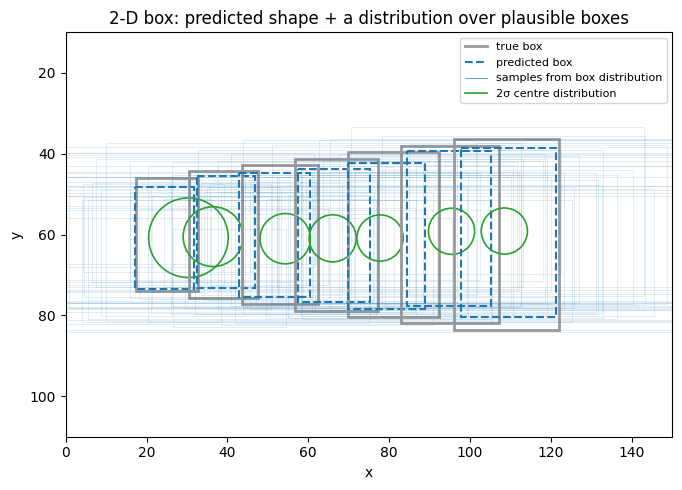

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(0, T, 2):
    draw_box(ax, true_box[k], edgecolor="0.6", lw=2)
    draw_box(ax, rec_box[k]["post_mean"], edgecolor="tab:blue", lw=1.5,
             linestyle="--")
    # samples from the predictive [x, y, a, h] distribution
    mu4 = rec_box[k]["prior_mean"][:4]
    S4 = rec_box[k]["prior_cov"][:4, :4] + torch.eye(4) * proc.r
    S4 = S4 + torch.eye(4) * 1e-6
    dist = torch.distributions.MultivariateNormal(mu4.double(), S4.double())
    for _ in range(12):
        draw_box(ax, dist.sample().float(), edgecolor="tab:blue",
                 lw=0.5, alpha=0.18)
    mu, S = predictive_xy(rec_box[k], proc.r)
    cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:green", lw=1.2)
ax.plot([], [], color="0.6", lw=2, label="true box")
ax.plot([], [], color="tab:blue", lw=1.5, ls="--", label="predicted box")
ax.plot([], [], color="tab:blue", lw=0.5, label="samples from box distribution")
ax.plot([], [], color="tab:green", lw=1.2, label="2σ centre distribution")
ax.set_xlim(0, 150); ax.set_ylim(110, 10)            # image convention
ax.set_aspect("equal")
ax.set_title("2-D box: predicted shape + a distribution over plausible boxes")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


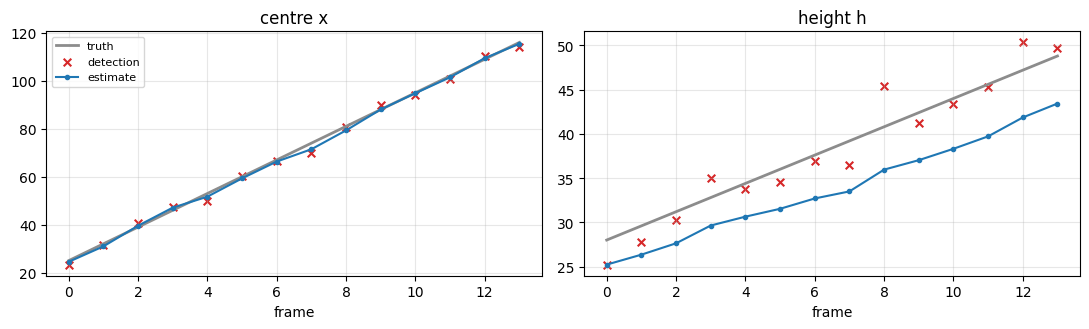

In [9]:
# The same run, as time series: the filter predicts size as well as place.
post_box = torch.stack([r["post_mean"] for r in rec_box])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, j, name in [(axes[0], 0, "centre x"), (axes[1], 3, "height h")]:
    ax.plot(t, true_box[:, j], "-", color="0.55", lw=2, label="truth")
    ax.scatter(t, meas_box[:, j], marker="x", color="tab:red", s=30,
               label="detection")
    ax.plot(t, post_box[:, j], "o-", color="tab:blue", ms=3, label="estimate")
    ax.set_title(name); ax.set_xlabel("frame"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 3 — 2-D masks

A segmentation mask is a bitmap, not a vector — a Kalman filter
cannot smooth pixels directly. The standard move is to track a
low-dimensional *summary* of the mask (here its **centroid**) with
`KalmanCentroid2D`, and carry the mask shape along for rendering. The
prediction then says "the blob's centre will be about here, with this
uncertainty," and you translate the mask template to that centre.

Left: the mask at each frame, time-graded light→dark, with the true
centroid path. Right: at one frame, the predicted mask (translated to
the prior centroid) and the 2σ ellipse for where the centre will land.


In [10]:
Himg, Wimg = 90, 170
ys, xs = torch.meshgrid(torch.arange(Himg), torch.arange(Wimg), indexing="ij")

def make_mask(cx, cy, rx=13.0, ry=8.0):
    return (((xs - cx) / rx) ** 2 + ((ys - cy) / ry) ** 2) <= 1.0

def mask_centroid(mask):
    idx = mask.nonzero().float()                     # rows are [y, x]
    return torch.stack([idx[:, 1].mean(), idx[:, 0].mean()])   # [x, y]

T = 12
t = torch.arange(T).float()
true_c = torch.stack([18.0 + 11.0 * t, 30.0 + 3.5 * t], dim=1)
masks = [make_mask(float(cx), float(cy)) for cx, cy in true_c]
g = torch.Generator().manual_seed(9)
meas_c = torch.stack([mask_centroid(m) for m in masks])             + 2.0 * torch.randn(T, 2, generator=g)

proc = KalmanCentroid2D("centroid", q=0.1, r=4.0)
init_mean = torch.tensor([float(meas_c[0, 0]), float(meas_c[0, 1]), 11.0, 3.5])
rec_m = run_kalman(proc, init_mean, torch.eye(4) * 6.0,
                   list(meas_c), [True] * T)


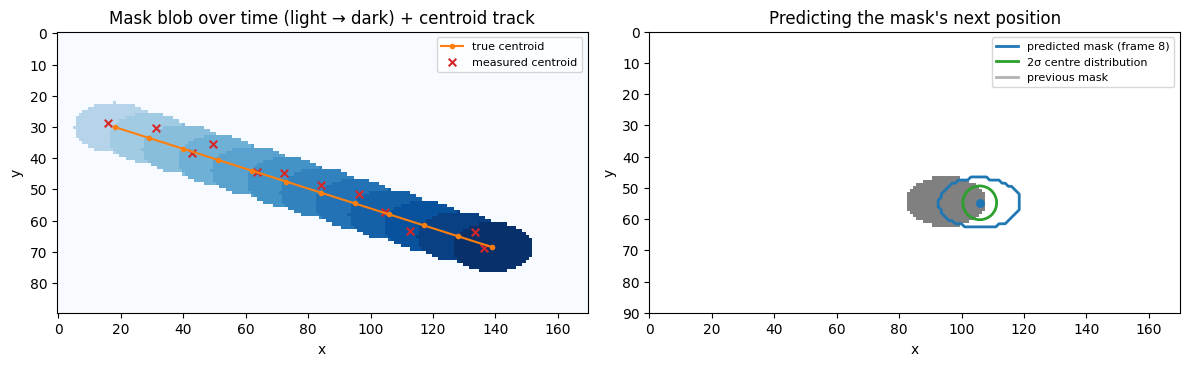

In [11]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))

# (left) masks over time + centroid trajectory
composite = torch.zeros(Himg, Wimg)
for k, m in enumerate(masks):
    composite = torch.maximum(composite, m.float() * (0.3 + 0.7 * k / (T - 1)))
axL.imshow(composite.numpy(), cmap="Blues", origin="upper")
axL.plot(true_c[:, 0], true_c[:, 1], "-o", color="tab:orange", ms=3,
         label="true centroid")
axL.scatter(meas_c[:, 0], meas_c[:, 1], marker="x", color="tab:red", s=30,
            label="measured centroid")
axL.set_title("Mask blob over time (light → dark) + centroid track")
axL.legend(fontsize=8); axL.set_xlabel("x"); axL.set_ylabel("y")

# (right) predicted mask + centre uncertainty at frame kf
kf = 8
axR.imshow(masks[kf - 1].numpy(), cmap="Greys", origin="upper", alpha=0.5)
pri = rec_m[kf]["prior_mean"][:2]
template = make_mask(float(pri[0]), float(pri[1]))   # mask at predicted centre
axR.contour(template.numpy(), levels=[0.5], colors="tab:blue", linewidths=2)
mu, S = predictive_xy(rec_m[kf], proc.r)
cov_ellipse(axR, mu, S, n_std=2.0, edgecolor="tab:green", lw=2)
axR.scatter([float(pri[0])], [float(pri[1])], color="tab:blue", s=30, zorder=3)
axR.plot([], [], color="tab:blue", lw=2, label="predicted mask (frame %d)" % kf)
axR.plot([], [], color="tab:green", lw=2, label="2σ centre distribution")
axR.plot([], [], color="0.4", lw=2, alpha=0.5, label="previous mask")
axR.set_xlim(0, Wimg); axR.set_ylim(Himg, 0)
axR.set_title("Predicting the mask's next position")
axR.legend(fontsize=8); axR.set_xlabel("x"); axR.set_ylabel("y")
plt.tight_layout(); plt.show()


## 4 — 3-D point clouds

For LiDAR-style tracking the object is a *cloud* of 3-D points; its
location is summarized by the cloud centroid, tracked with
`KalmanCentroid3D` (state `[x,y,z, vx,vy,vz]`, measurement
`[x, y, z]`). The predictive distribution is now a 3-D Gaussian — we
draw it as a 2σ **wireframe ellipsoid** around the predicted centroid.

The faded clouds show the object at three frames; the orange line is
the true centroid path; the green ellipsoid is where the filter
expects the centroid next, given only the earlier frames.


In [12]:
def plot_ellipsoid(ax, mean3, cov3, n_std=2.0, **kw):
    cov3 = cov3.detach().cpu().double().numpy()
    u = np.linspace(0, 2 * np.pi, 24)
    v = np.linspace(0, np.pi, 14)
    sphere = np.stack([
        np.outer(np.cos(u), np.sin(v)),
        np.outer(np.sin(u), np.sin(v)),
        np.outer(np.ones_like(u), np.cos(v)),
    ]).reshape(3, -1)
    L = np.linalg.cholesky(cov3 + np.eye(3) * 1e-9) * n_std
    pts = (L @ sphere) + mean3.detach().cpu().numpy()[:, None]
    P = pts.reshape(3, u.size, v.size)
    ax.plot_wireframe(P[0], P[1], P[2], **kw)

T = 14
t = torch.arange(T).float()
true_c3 = torch.stack([1.5 * t, 0.4 * t, 5.0 + 0.5 * torch.sin(0.4 * t)], dim=1)
g = torch.Generator().manual_seed(11)
clouds = [c + 0.6 * torch.randn(160, 3, generator=g) for c in true_c3]
meas_c3 = torch.stack([cloud.mean(0) for cloud in clouds])             + 0.25 * torch.randn(T, 3, generator=g)

proc = KalmanCentroid3D("centroid", q=0.05, r=0.1)
init_mean = torch.zeros(6)
init_mean[:3] = meas_c3[0]
init_mean[3:5] = torch.tensor([1.5, 0.4])
rec3 = run_kalman(proc, init_mean, torch.eye(6) * 2.0,
                  list(meas_c3), [True] * T)
post3 = torch.stack([r["post_mean"][:3] for r in rec3])


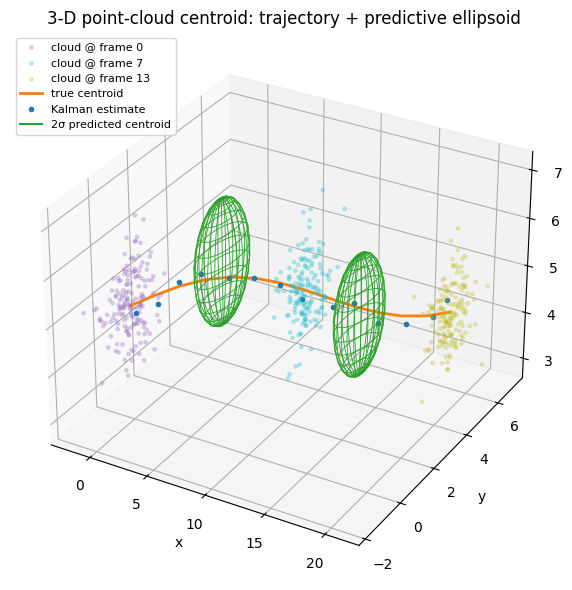

In [13]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(projection="3d")
for k, col in [(0, "tab:purple"), (T // 2, "tab:cyan"), (T - 1, "tab:olive")]:
    c = clouds[k]
    ax.scatter(c[:, 0], c[:, 1], c[:, 2], s=6, alpha=0.25, color=col,
               label=f"cloud @ frame {k}")
ax.plot(true_c3[:, 0], true_c3[:, 1], true_c3[:, 2], "-", color="tab:orange",
        lw=2, label="true centroid")
ax.plot(post3[:, 0], post3[:, 1], post3[:, 2], "o", color="tab:blue", ms=3,
        label="Kalman estimate")
for k in (4, 9):
    mu3 = rec3[k]["prior_mean"][:3]
    S3 = rec3[k]["prior_cov"][:3, :3] + torch.eye(3) * proc.r
    plot_ellipsoid(ax, mu3, S3, n_std=2.0, color="tab:green", lw=0.6)
ax.plot([], [], color="tab:green", label="2σ predicted centroid")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("3-D point-cloud centroid: trajectory + predictive ellipsoid")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()


## 5 — Kernel / appearance states

Appearance embeddings (ReID kernels) have no velocity — there is no
"motion model" for a feature vector. But a Kalman filter still helps:
model the embedding as a **random walk** (`F = I`, so the predict
step only inflates covariance) and the update becomes a principled,
uncertainty-weighted smoother — EMA's grown-up cousin, where the
blend rate is set by how trustworthy each observation is rather than
a fixed `ρ`.

We build this directly from the `KalmanLinear` backbone with `F = H =
I`. The embedding is 2-D here so we can watch it; in practice it is
512-D, but the recursion is identical. A slowly drifting appearance
(lighting, pose) is tracked through heavy per-frame noise.


In [14]:
class RandomWalkKalman:
    """F = H = I Kalman: a smoother for no-motion (appearance) states."""
    def __init__(self, field, dim, q, r):
        self.field, self.dim, self.r = field, dim, r
        eye = torch.eye(dim)
        self._proc = KalmanLinear(field=field, F=eye, H=eye,
                                  Q=eye * q, R=eye * r)
        self._upd = KalmanUpdate(field=field, cov_field=f"{field}_cov",
                                 H=eye, R=eye * r)
    def __call__(self, cs, ctx):
        return self._proc(cs, ctx)
    def make_update(self):
        return self._upd

T = 26
t = torch.arange(T).float()
true_emb = torch.stack([torch.cos(0.18 * t), 0.6 * torch.sin(0.18 * t)], dim=1)
g = torch.Generator().manual_seed(13)
emb_noise = 0.35
meas_emb = true_emb + emb_noise * torch.randn(T, 2, generator=g)

proc = RandomWalkKalman("emb", dim=2, q=0.01, r=emb_noise ** 2)
rec_e = run_kalman(proc, meas_emb[0], torch.eye(2) * 0.3,
                   list(meas_emb), [True] * T)
post_e = torch.stack([r["post_mean"] for r in rec_e])


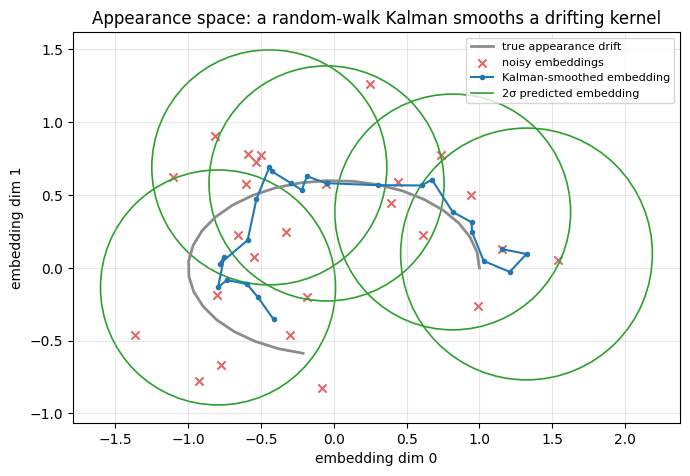

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(true_emb[:, 0], true_emb[:, 1], "-", color="0.55", lw=2,
        label="true appearance drift")
ax.scatter(meas_emb[:, 0], meas_emb[:, 1], marker="x", color="tab:red",
           s=35, alpha=0.7, label="noisy embeddings")
ax.plot(post_e[:, 0], post_e[:, 1], "o-", color="tab:blue", ms=3,
        label="Kalman-smoothed embedding")
for k in range(2, T, 5):
    mu, S = predictive_xy(rec_e[k], proc.r)
    cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:green", lw=1.2)
ax.plot([], [], color="tab:green", lw=1.2, label="2σ predicted embedding")
ax.set_title("Appearance space: a random-walk Kalman smooths a drifting kernel")
ax.set_xlabel("embedding dim 0"); ax.set_ylabel("embedding dim 1")
ax.legend(fontsize=8); ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


A caveat worth stating: a linear-Gaussian filter lives in flat
Euclidean space, but ReID embeddings usually live on the unit sphere
(cosine similarity). Smoothing then nudging back onto the sphere
(re-normalising) is a pragmatic hack, not exact inference — which is
why appearance is the state type where Kalman is *least* natural, and
a fixed-rate EMA is often preferred. Use it when the embedding really
does wander slowly and you want uncertainty-aware blending.


## 6 — Complex examples: where it works, where it breaks

The Kalman filter is optimal only when its assumptions hold: a
*linear* motion model, *Gaussian* noise, and noise covariances `Q`
(process) and `R` (measurement) that actually match reality. Tracking
violates all three routinely. This section makes the failure modes
concrete — each is a situation you will meet in a real video.


### 6a — Success: heavy noise, steady motion

The case the filter was made for. Measurement noise is large, but the
motion is genuinely constant-velocity, so averaging over time wins:
the estimate is far smoother and closer to truth than the raw
detections. This is the baseline "it just works."


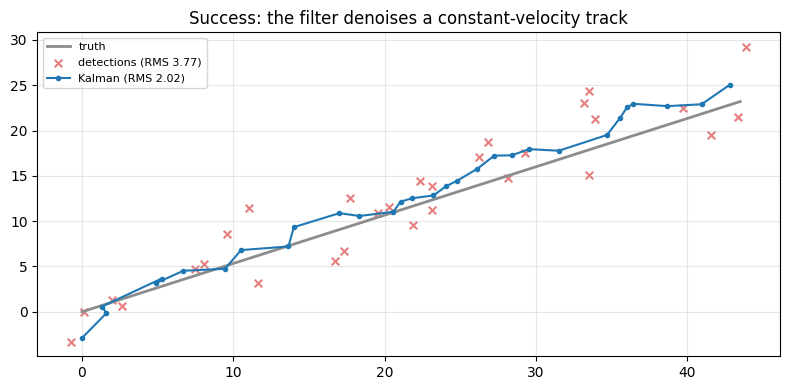

raw detection RMS error: 3.77   Kalman RMS error: 2.02


In [16]:
T = 30
t = torch.arange(T).float()
truth = torch.stack([1.5 * t, 0.8 * t], dim=1)
g = torch.Generator().manual_seed(21)
noisy = truth + 3.0 * torch.randn(T, 2, generator=g)
proc = KalmanCentroid2D("centroid", q=0.02, r=9.0)
m0 = torch.tensor([float(noisy[0, 0]), float(noisy[0, 1]), 1.5, 0.8])
rec = run_kalman(proc, m0, torch.eye(4) * 5.0, list(noisy), [True] * T)
est = torch.stack([r["post_mean"][:2] for r in rec])
rms_raw = (noisy - truth).pow(2).sum(1).mean().sqrt()
rms_kf = (est - truth).pow(2).sum(1).mean().sqrt()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2, label="truth")
ax.scatter(noisy[:, 0], noisy[:, 1], marker="x", color="tab:red", s=30,
           alpha=0.6, label=f"detections (RMS {rms_raw:.2f})")
ax.plot(est[:, 0], est[:, 1], "o-", color="tab:blue", ms=3,
        label=f"Kalman (RMS {rms_kf:.2f})")
ax.set_title("Success: the filter denoises a constant-velocity track")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"raw detection RMS error: {rms_raw:.2f}   Kalman RMS error: {rms_kf:.2f}")


### 6b — Failure: a maneuvering target

A constant-velocity model assumes the object does not accelerate.
When the target makes a hard 90° turn, the filter — still confident
in the old velocity — overshoots, and for several frames the **true
position falls outside the 2σ predictive ellipse**. In a real
tracker that is fatal: a Mahalanobis gate would reject the *correct*
detection as too far away, and the track either dies or steals
someone else's detection. The red ✕ marks frames where the truth is
outside the gate.


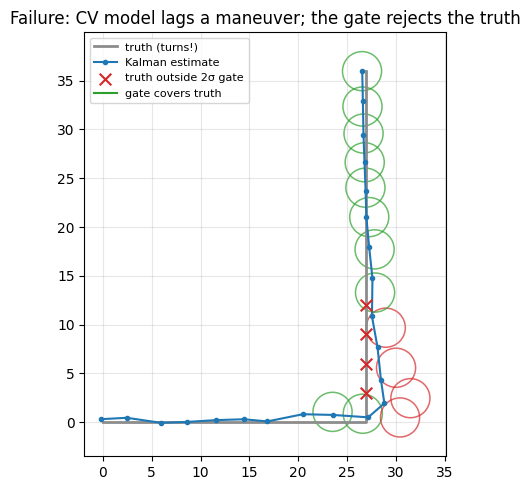

frames where truth left the 2σ gate: 4 / 22


In [17]:
# An L-shaped path: east for 10 frames, then a sharp turn north.
leg = torch.arange(10).float()
east = torch.stack([3.0 * leg, torch.zeros(10)], dim=1)
north = torch.stack([27.0 + torch.zeros(12), 3.0 * torch.arange(1, 13).float()],
                    dim=1)
truth = torch.cat([east, north], dim=0)
T = truth.shape[0]
g = torch.Generator().manual_seed(23)
meas = truth + 0.6 * torch.randn(T, 2, generator=g)

proc = KalmanCentroid2D("centroid", q=0.05, r=0.4)
m0 = torch.tensor([0.0, 0.0, 3.0, 0.0])
rec = run_kalman(proc, m0, torch.eye(4) * 2.0, list(meas), [True] * T)
est = torch.stack([r["post_mean"][:2] for r in rec])

# Which frames is the truth outside the 2-sigma predictive gate?
outside = []
for k in range(T):
    mu, S = predictive_xy(rec[k], proc.r)
    d = (truth[k] - mu).double()
    md2 = float(d @ torch.linalg.inv(S.double()) @ d)   # squared Mahalanobis
    outside.append(md2 > 5.991)                          # chi2(2dof, .95)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2, label="truth (turns!)")
ax.plot(est[:, 0], est[:, 1], "o-", color="tab:blue", ms=3, label="Kalman estimate")
for k in range(8, T):
    mu, S = predictive_xy(rec[k], proc.r)
    col = "tab:red" if outside[k] else "tab:green"
    cov_ellipse(ax, mu, S, n_std=2.0, edgecolor=col, lw=1.1, alpha=0.7)
miss = torch.tensor(outside)
ax.scatter(truth[miss, 0], truth[miss, 1], marker="x", color="tab:red", s=70,
           zorder=4, label="truth outside 2σ gate")
ax.plot([], [], color="tab:green", label="gate covers truth")
ax.set_title("Failure: CV model lags a maneuver; the gate rejects the truth")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print(f"frames where truth left the 2σ gate: {int(miss.sum())} / {T}")


The fix in practice is to admit you do not know the acceleration:
raise `q` so the predictive covariance grows fast enough to keep the
truth inside the gate. That is the next failure mode — tuning.


### 6c — Failure: mistuned noise (`q` too small vs. too large)

`q` encodes "how much can the object surprise me between frames?"
Set it too **small** and the filter is overconfident: tight ellipses,
sluggish to follow the maneuver, the estimate lags badly. Set it too
**large** and the filter distrusts its own model, chases every noisy
detection, and the estimate is jittery. Only the middle setting both
follows the turn *and* stays smooth — the RMS error is U-shaped in
`q`. Same L-path as above, now with noisier detections so both
failure modes show.


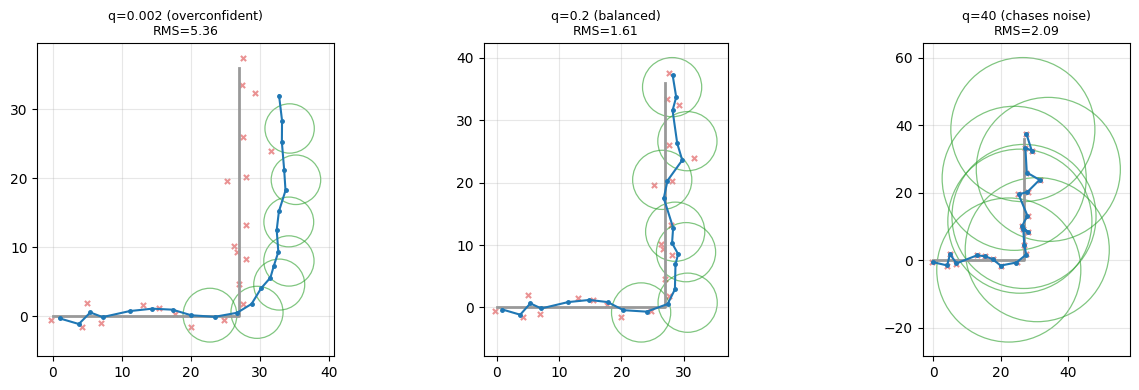

In [18]:
g = torch.Generator().manual_seed(31)
meas_n = truth + 1.6 * torch.randn(T, 2, generator=g)   # noisier detections

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, q, label in [(axes[0], 0.002, "q=0.002 (overconfident)"),
                     (axes[1], 0.2, "q=0.2 (balanced)"),
                     (axes[2], 40.0, "q=40 (chases noise)")]:
    proc = KalmanCentroid2D("centroid", q=q, r=2.5)
    rec = run_kalman(proc, torch.tensor([0., 0, 3, 0]),
                     torch.eye(4) * 2.0, list(meas_n), [True] * T)
    est = torch.stack([r["post_mean"][:2] for r in rec])
    rms = (est - truth).pow(2).sum(1).mean().sqrt()
    ax.plot(truth[:, 0], truth[:, 1], "-", color="0.6", lw=2)
    ax.scatter(meas_n[:, 0], meas_n[:, 1], marker="x", color="tab:red", s=14,
               alpha=0.5)
    ax.plot(est[:, 0], est[:, 1], "o-", color="tab:blue", ms=2.5)
    for k in range(8, T, 2):
        mu, S = predictive_xy(rec[k], proc.r)
        cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:green", lw=0.9,
                    alpha=0.6)
    ax.set_title(f"{label}\nRMS={rms:.2f}", fontsize=9)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6d — Failure: crossing targets and ambiguous gates

Motion prediction alone cannot keep two identities apart when their
predictive distributions overlap. Two objects cross paths; near the
crossing, each filter's 2σ ellipse contains *both* detections, so the
association is a coin-flip — this is the classic point at which a
pure-motion tracker swaps IDs. The lesson is structural: Kalman
motion is necessary but not sufficient; an appearance cue (section 5)
is what breaks the tie. The shaded frame marks the ambiguous window.


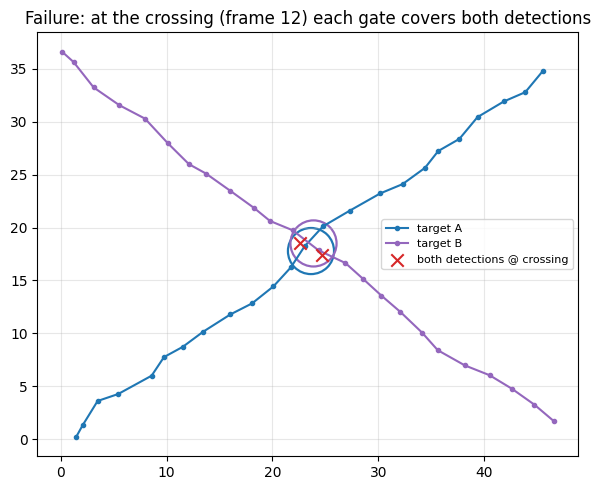

In [19]:
T = 24
t = torch.arange(T).float()
# Two targets crossing at the midpoint.
A = torch.stack([2.0 * t, 1.5 * t], dim=1)
B = torch.stack([2.0 * t, 36.0 - 1.5 * t], dim=1)
g = torch.Generator().manual_seed(27)
mA = A + 0.7 * torch.randn(T, 2, generator=g)
mB = B + 0.7 * torch.randn(T, 2, generator=g)

def track(meas, vy):
    proc = KalmanCentroid2D("centroid", q=0.05, r=0.5)
    m0 = torch.tensor([float(meas[0, 0]), float(meas[0, 1]), 2.0, vy])
    return proc, run_kalman(proc, m0, torch.eye(4) * 2.0, list(meas), [True] * T)

procA, recA = track(mA, 1.5)
procB, recB = track(mB, -1.5)

# Find the most ambiguous frame: ellipses closest / most overlapping.
kx = int(torch.argmin(torch.stack(
    [(recA[k]["prior_mean"][:2] - recB[k]["prior_mean"][:2]).norm()
     for k in range(T)])))

fig, ax = plt.subplots(figsize=(8, 5))
for rec_, proc_, col, name in [(recA, procA, "tab:blue", "target A"),
                               (recB, procB, "tab:purple", "target B")]:
    est = torch.stack([r["post_mean"][:2] for r in rec_])
    ax.plot(est[:, 0], est[:, 1], "o-", color=col, ms=3, label=name)
    mu, S = predictive_xy(rec_[kx], proc_.r)
    cov_ellipse(ax, mu, S, n_std=2.0, edgecolor=col, lw=1.6)
ax.scatter([float(mA[kx, 0]), float(mB[kx, 0])],
           [float(mA[kx, 1]), float(mB[kx, 1])],
           marker="x", color="tab:red", s=80, zorder=4,
           label="both detections @ crossing")
ax.set_title(f"Failure: at the crossing (frame {kx}) each gate covers both detections")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


### 6e — Success: estimating a state you never measure

The detector reports only position, yet the filter needs *velocity*
to predict. The Kalman filter infers it: velocity is an unobserved
part of the state, and the correlations `F` induces between position
and velocity let measurements of position update the velocity belief
too. Below we deliberately initialise velocity at **zero** (wrong);
within a handful of frames the estimated `(vx, vy)` lock onto the
true values, and the ±2σ band — read straight off the covariance —
shrinks as confidence grows. Nothing ever measured velocity directly.


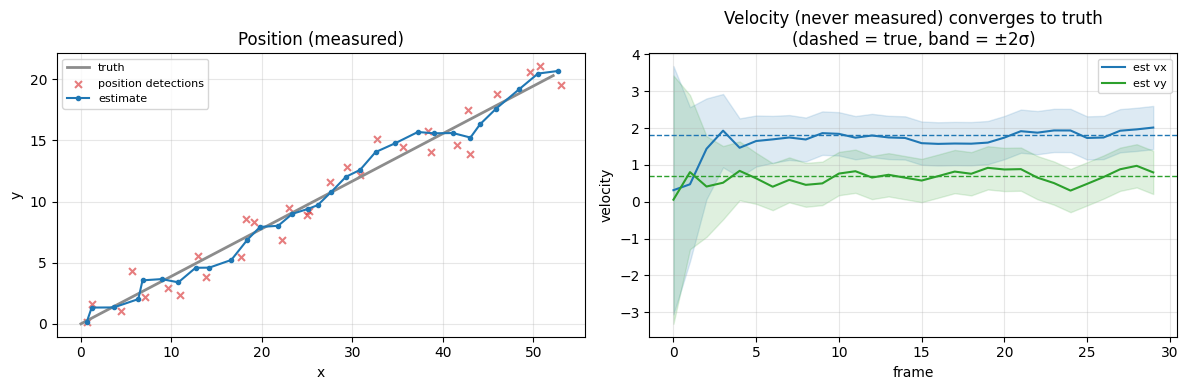

In [20]:
T = 30
t = torch.arange(T).float()
true_v = torch.tensor([1.8, 0.7])
truth = t[:, None] * true_v                       # constant velocity
g = torch.Generator().manual_seed(33)
meas = truth + 1.2 * torch.randn(T, 2, generator=g)

proc = KalmanCentroid2D("centroid", q=0.02, r=1.44)
m0 = torch.tensor([0.0, 0.0, 0.0, 0.0])           # WRONG: zero velocity
rec = run_kalman(proc, m0, torch.eye(4) * 5.0, list(meas), [True] * T)

est = torch.stack([r["post_mean"] for r in rec])   # [x, y, vx, vy]
std = torch.stack([r["post_cov"].diagonal().clamp(min=0).sqrt() for r in rec])

fig, (axp, axv) = plt.subplots(1, 2, figsize=(12, 4))
axp.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2, label="truth")
axp.scatter(meas[:, 0], meas[:, 1], marker="x", color="tab:red", s=25,
            alpha=0.6, label="position detections")
axp.plot(est[:, 0], est[:, 1], "o-", color="tab:blue", ms=3, label="estimate")
axp.set_title("Position (measured)"); axp.legend(fontsize=8); axp.grid(alpha=0.3)
axp.set_xlabel("x"); axp.set_ylabel("y")

for j, name, col in [(2, "vx", "tab:blue"), (3, "vy", "tab:green")]:
    axv.plot(t, est[:, j], "-", color=col, label=f"est {name}")
    axv.fill_between(t, est[:, j] - 2 * std[:, j], est[:, j] + 2 * std[:, j],
                     color=col, alpha=0.15)
    axv.axhline(float(true_v[j - 2]), ls="--", color=col, lw=1)
axv.set_title("Velocity (never measured) converges to truth\n(dashed = true, band = ±2σ)")
axv.set_xlabel("frame"); axv.set_ylabel("velocity"); axv.legend(fontsize=8)
axv.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6f — Failure, then fix: a clutter detection (outlier)

Kalman assumes Gaussian noise, so a single gross outlier — a false
positive, a detection snapped to the wrong object — is wildly
unlikely under the model, and the filter has no idea it should
distrust it. Fused naively, one outlier yanks the estimate off the
track for several frames (left). The standard defense is a **gate**:
reject any detection whose Mahalanobis distance to the predictive
distribution is too large (here χ² > 9.21, the 99% bound for 2 dof),
treating it as a miss. The same two outliers are now rejected and the
track stays clean (right). This is exactly why association in a real
tracker runs *through* the predictive gate.


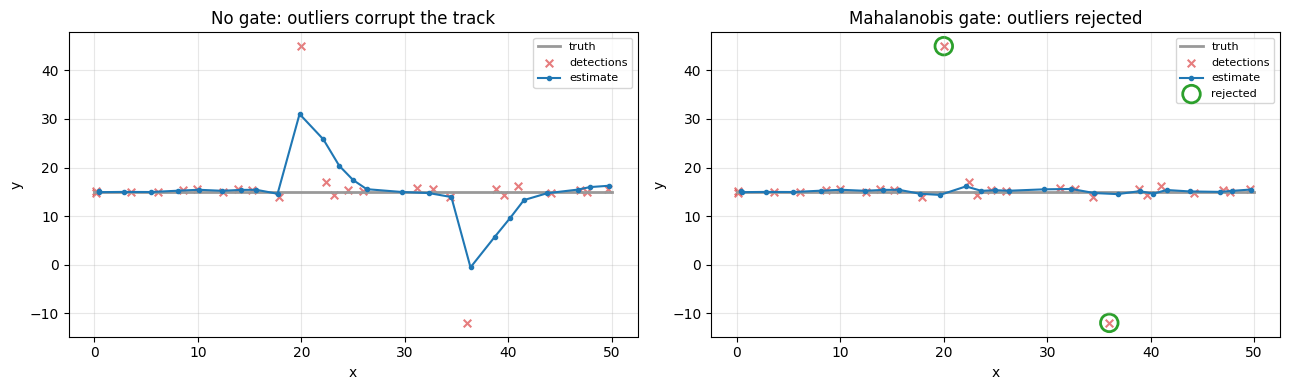

In [21]:
T = 26
t = torch.arange(T).float()
truth = torch.stack([2.0 * t, 15.0 + torch.zeros(T)], dim=1)
g = torch.Generator().manual_seed(35)
meas = truth + 0.8 * torch.randn(T, 2, generator=g)
meas[10] = torch.tensor([20.0, 45.0])             # clutter
meas[18] = torch.tensor([36.0, -12.0])            # clutter

def make_proc():
    return KalmanCentroid2D("centroid", q=0.05, r=0.7)
m0 = torch.tensor([0.0, 15.0, 2.0, 0.0])
rec_no = run_kalman(make_proc(), m0, torch.eye(4) * 2.0, list(meas), [True] * T)
rec_g = run_kalman(make_proc(), m0, torch.eye(4) * 2.0, list(meas), [True] * T,
                   gate_chi2=9.21)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, rec, title in [(axes[0], rec_no, "No gate: outliers corrupt the track"),
                       (axes[1], rec_g, "Mahalanobis gate: outliers rejected")]:
    est = torch.stack([r["post_mean"][:2] for r in rec])
    ax.plot(truth[:, 0], truth[:, 1], "-", color="0.6", lw=2, label="truth")
    ax.scatter(meas[:, 0], meas[:, 1], marker="x", color="tab:red", s=30,
               alpha=0.6, label="detections")
    ax.plot(est[:, 0], est[:, 1], "o-", color="tab:blue", ms=3, label="estimate")
    gated = [k for k, r in enumerate(rec) if r["gated"]]
    if gated:
        ax.scatter(meas[gated, 0], meas[gated, 1], s=160, facecolors="none",
                   edgecolors="tab:green", linewidths=2, label="rejected")
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


### 6g — Failure: constant acceleration → systematic lag

Section 6b broke the filter with a *sharp* turn. A *smooth*
violation is sneakier: a target under constant acceleration. The
constant-velocity model never predicts the speed-up, so its estimate
trails the truth by a roughly **constant lag** that the update step
can shrink but never erase — a persistent bias, not noise. Raising
`q` lets the filter believe the velocity can change and cuts the lag,
but the principled fix is a constant-acceleration model. The right
panel shows the lag stays bounded-but-nonzero for low `q`.


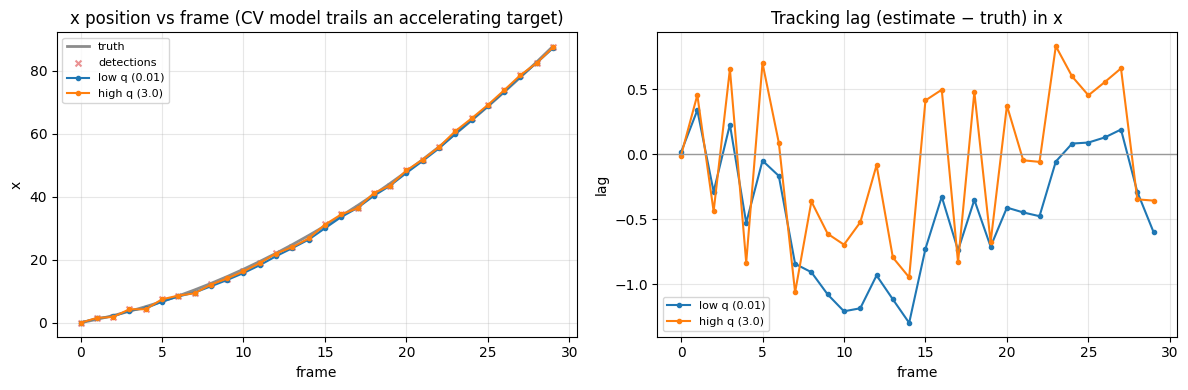

In [22]:
T = 30
t = torch.arange(T).float()
accel = 0.14
x = 0.5 * accel * t ** 2 + 1.0 * t                # accelerating along x
truth = torch.stack([x, torch.zeros(T)], dim=1)
g = torch.Generator().manual_seed(37)
meas = truth + 0.5 * torch.randn(T, 2, generator=g)

runs = {}
for q, name in [(0.01, "low q (0.01)"), (3.0, "high q (3.0)")]:
    proc = KalmanCentroid2D("centroid", q=q, r=0.25)
    rec = run_kalman(proc, torch.tensor([0.0, 0.0, 1.0, 0.0]),
                     torch.eye(4) * 2.0, list(meas), [True] * T)
    runs[name] = torch.stack([r["post_mean"][:2] for r in rec])

fig, (axx, axl) = plt.subplots(1, 2, figsize=(12, 4))
axx.plot(t, truth[:, 0], "-", color="0.55", lw=2, label="truth")
axx.scatter(t, meas[:, 0], marker="x", color="tab:red", s=18, alpha=0.5,
            label="detections")
for name, est in runs.items():
    axx.plot(t, est[:, 0], "o-", ms=3, label=name)
axx.set_title("x position vs frame (CV model trails an accelerating target)")
axx.set_xlabel("frame"); axx.set_ylabel("x"); axx.legend(fontsize=8)
axx.grid(alpha=0.3)

for name, est in runs.items():
    axl.plot(t, (est[:, 0] - truth[:, 0]), "o-", ms=3, label=name)
axl.axhline(0, color="0.6", lw=1)
axl.set_title("Tracking lag (estimate − truth) in x")
axl.set_xlabel("frame"); axl.set_ylabel("lag"); axl.legend(fontsize=8)
axl.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6h — Failure: a maneuver *during* a long occlusion

Two safe situations combine into a dangerous one. Coasting through an
occlusion is fine if the motion stays constant (section 1); a
maneuver is survivable if the object stays *visible* so the update can
correct it (section 6b). But if the object turns **while occluded**,
there is no measurement to catch the change: the filter coasts in a
straight line, and when the object reappears the detection is nowhere
near the prediction. Even with the occlusion-inflated gate, the true
detection is rejected — the track is lost or, worse, steals a
neighbour's detection.


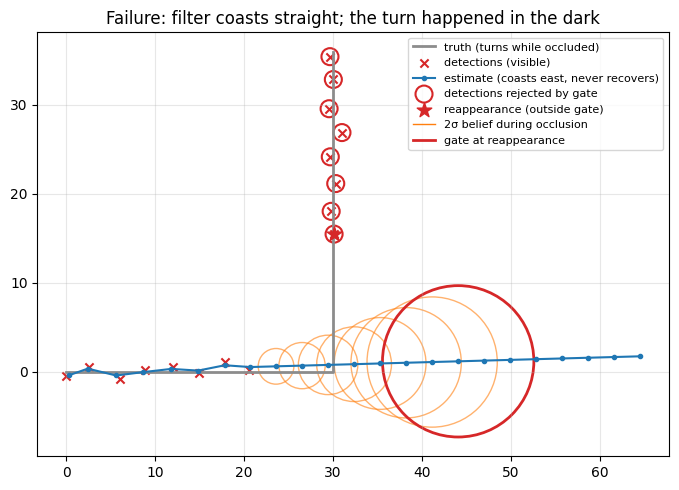

In [23]:
# East for 11 frames, then north — but the turn falls inside the gap.
present = [True] * 8 + [False] * 7 + [True] * 8        # occluded 8..14
T = len(present)
truth = []
for k in range(T):
    if k <= 10:
        truth.append([3.0 * k, 0.0])                  # heading east
    else:
        truth.append([30.0, 3.0 * (k - 10)])          # turned north
truth = torch.tensor(truth)
g = torch.Generator().manual_seed(39)
meas = truth + 0.6 * torch.randn(T, 2, generator=g)

# A gated tracker: a reappearance outside the predictive gate is rejected.
proc = KalmanCentroid2D("centroid", q=0.05, r=0.4)
rec = run_kalman(proc, torch.tensor([0.0, 0.0, 3.0, 0.0]),
                 torch.eye(4) * 2.0, list(meas), present, gate_chi2=9.21)
est = torch.stack([r["post_mean"][:2] for r in rec])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2,
        label="truth (turns while occluded)")
seen = torch.tensor(present)
ax.scatter(meas[seen, 0], meas[seen, 1], marker="x", color="tab:red", s=35,
           label="detections (visible)")
ax.plot(est[:, 0], est[:, 1], "o-", color="tab:blue", ms=3,
        label="estimate (coasts east, never recovers)")
rej = [k for k, r in enumerate(rec) if r["gated"]]
if rej:
    ax.scatter(meas[rej, 0], meas[rej, 1], s=150, facecolors="none",
               edgecolors="tab:red", linewidths=1.5,
               label="detections rejected by gate")
# coasting belief through the gap
for k in range(T):
    if not present[k]:
        mu, S = predictive_xy(rec[k], proc.r)
        cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:orange", lw=1.0,
                    alpha=0.6)
kf = 15                                               # reappearance frame
mu, S = predictive_xy(rec[kf], proc.r)
cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:red", lw=2)
ax.scatter([float(meas[kf, 0])], [float(meas[kf, 1])], s=120, color="tab:red",
           marker="*", zorder=5, label="reappearance (outside gate)")
ax.plot([], [], color="tab:orange", lw=1.0, label="2σ belief during occlusion")
ax.plot([], [], color="tab:red", lw=2, label="gate at reappearance")
ax.set_title("Failure: filter coasts straight; the turn happened in the dark")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


### 6i — Success: irregular frame rates (dt-aware prediction)

Real video is not metronomic: frames drop, sensors run at different
rates, clips are sampled unevenly. unitrack's Kalman processes take
the time step from `ctx.delta`, so `F` advances by the *actual* `dt`
and `Q` injects `q · dt` of process noise — predictions and gates stay
calibrated across uneven gaps. The left panel passes the true
per-frame `dt`; the right wrongly assumes a fixed `dt = 1`. With the
true `dt` the one-step predictions (green) land on the next detection;
with a fixed `dt` they undershoot the long gaps and the gate sits
behind the object — the kind of silent miscalibration that quietly
loses tracks.


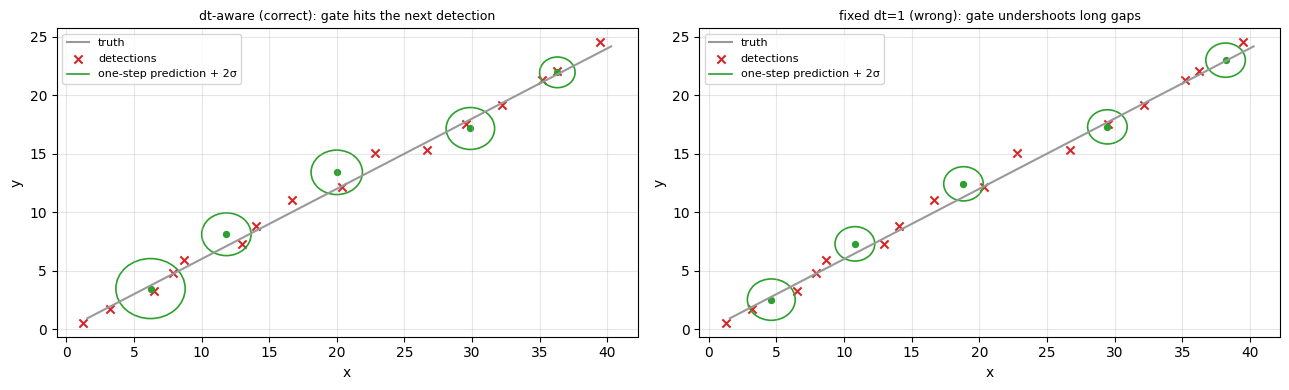

In [24]:
T = 16
g = torch.Generator().manual_seed(41)
dts = (0.4 + 1.6 * torch.rand(T, generator=g))        # irregular steps
times = torch.cumsum(dts, 0)
vel = torch.tensor([2.0, 1.2])
truth = times[:, None] * vel                          # CV in continuous time
meas = truth + 0.4 * torch.randn(T, 2, generator=g)

m0 = torch.tensor([float(meas[0, 0]), float(meas[0, 1]), 2.0, 1.2])
rec_ok = run_kalman(KalmanCentroid2D("centroid", q=0.05, r=0.16),
                    m0, torch.eye(4) * 1.0, list(meas), [True] * T,
                    dts=list(dts))
rec_bad = run_kalman(KalmanCentroid2D("centroid", q=0.05, r=0.16),
                     m0, torch.eye(4) * 1.0, list(meas), [True] * T,
                     dt=1.0)                            # ignores real dt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, rec, title in [(axes[0], rec_ok, "dt-aware (correct): gate hits the next detection"),
                       (axes[1], rec_bad, "fixed dt=1 (wrong): gate undershoots long gaps")]:
    ax.plot(truth[:, 0], truth[:, 1], "-", color="0.6", lw=1.5, label="truth")
    ax.scatter(meas[:, 0], meas[:, 1], marker="x", color="tab:red", s=35,
               label="detections")
    for k in range(2, T, 3):
        mu, S = predictive_xy(rec[k], 0.16)
        cov_ellipse(ax, mu, S, n_std=2.0, edgecolor="tab:green", lw=1.2)
        ax.scatter([float(mu[0])], [float(mu[1])], color="tab:green", s=18)
    ax.plot([], [], color="tab:green", lw=1.2, label="one-step prediction + 2σ")
    ax.set_title(title, fontsize=9); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## Takeaways

- **Predict + update is the whole filter.** Predict produces a
  *distribution* over the next measurement; update fuses a detection
  and shrinks it. The ellipses/ellipsoids in every plot are that
  predictive distribution — and they double as the association gate.
- **The state type only changes `F`, `H`, and the measurement.**
  Points, boxes, mask centroids, 3-D clouds and appearance kernels
  are all the same recursion with different matrices — which is why
  unitrack exposes them as one `Process` + `KalmanUpdate` family.
- **It excels** at denoising steady motion, coasting through short
  occlusions, inferring states it never measures (velocity from
  position alone, 6e), and staying calibrated under irregular frame
  rates via `dt`-aware `F`/`Q` (6i).
- **It breaks** under maneuvers (model mismatch, 6b), constant
  acceleration (systematic lag, 6g), bad `q`/`r` tuning (6c),
  non-Gaussian clutter unless you gate (6f), turns hidden inside a
  long occlusion (6h), and identity ambiguity when predictive gates
  overlap (6d). Tuning fixes some; the rest need a better motion
  model, an outlier gate, or an appearance partner.
- **The predictive gate is the workhorse.** Almost every failure
  above is *detected* by asking "is the detection inside the 2σ
  ellipse?" — the same Mahalanobis test that rejects clutter (6f),
  flags a maneuver (6b), and exposes a miscalibrated `dt` (6i).

In unitrack you rarely drive the filter by hand as we did here.
Drop any of these processes into a `Tracker` via `state_entries(...)`
and the predict/update loop, gating, and lifecycle are handled for
you — see the tutorial notebooks under `notebooks/tutorials/`
(notebook 5 covers states and lifecycle end to end).
